# Part D: Cross-Validation Strategies
**Robust Regression Engine**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import (
    KFold, StratifiedKFold, LeaveOneOut,
    TimeSeriesSplit, cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"D:\Python_rnw\one\supervised learning\PR2\Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")

TARGET    = 'house_price_inr'
DROP_COLS = ['property_id', 'sale_date']
FEATURES  = [col for col in df.columns if col not in [TARGET] + DROP_COLS]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Ridge(alpha=1000)

print("Data Ready")
print(X_train.shape)

Data Ready
(3040, 9)


## Task 13 — K-Fold Cross-Validation

In [4]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='r2'
)

print("Cross Validation Scores :", cv_scores)
print("Average CV Score        :", cv_scores.mean())

Cross Validation Scores : [0.84650283 0.83576365 0.86830465 0.85396858 0.8485353 ]
Average CV Score        : 0.8506150029383137


## Task 13 — Stratified K-Fold Cross-Validation

In [5]:
# Create charge category for stratification
y_bins = pd.qcut(y_train, q=5, labels=False, duplicates='drop')

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=list(skf.split(X_train_scaled, y_bins)),
    scoring='r2'
)

print("Scores  :", scores)
print("Average :", scores.mean())

Scores  : [0.84144444 0.84404175 0.85846751 0.86000272 0.84923661]
Average : 0.8506386067339765


## Task 13 — Leave-One-Out Cross-Validation (LOOCV)

In [6]:
# Using subset of 200 rows for speed (LOOCV runs N iterations)
X_sub = X_train_scaled[:200]
y_sub = y_train.values[:200]

loo = LeaveOneOut()

loo_scores = cross_val_score(
    model,
    X_sub,
    y_sub,
    cv=loo,
    scoring='neg_mean_squared_error'
)

print("Cross Validation Scores :", loo_scores[:10], "...")
print("Mean MSE :", abs(loo_scores.mean()))

Cross Validation Scores : [-3.20659917e+13 -5.46124195e+13 -1.80978219e+12 -3.72457654e+13
 -1.92232435e+13 -4.28410679e+13 -2.67775651e+11 -1.92889561e+12
 -6.35698490e+12 -2.76468036e+12] ...
Mean MSE : 41626877506949.04


## Task 13 — Time Series Split (sorted by sale_date)

In [9]:
df_ts = pd.read_csv(r"D:\Python_rnw\one\supervised learning\PR2\Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")
df_ts['sale_date'] = pd.to_datetime(df_ts['sale_date'])
df_ts = df_ts.sort_values('sale_date').reset_index(drop=True)

X_ts = df_ts[FEATURES].values
y_ts = df_ts[TARGET].values
X_ts_scaled = StandardScaler().fit_transform(X_ts)

tscv = TimeSeriesSplit(n_splits=5)

ts_scores = cross_val_score(
    model,
    X_ts_scaled,
    y_ts,
    cv=tscv,
    scoring='r2'
)

print("Scores       :", ts_scores)
print("Average Score:", ts_scores.mean())

Scores       : [0.68763629 0.8038236  0.83237473 0.84783819 0.86811376]
Average Score: 0.807957312558915


## Task 14 — Analyze Performance Across CV Strategies

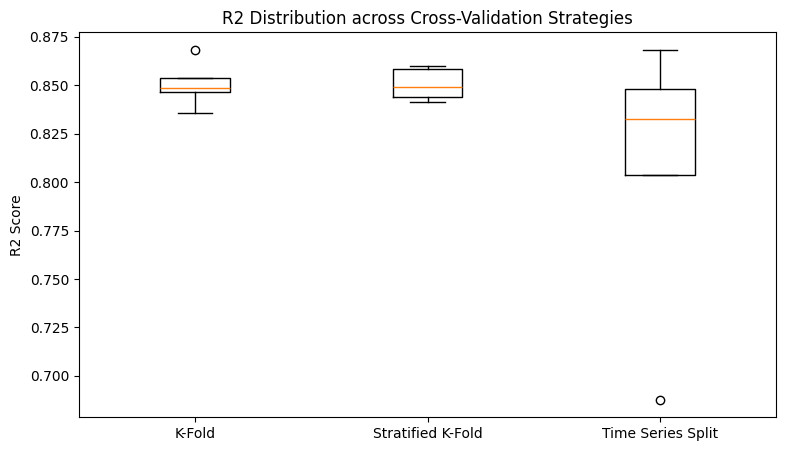


Summary:
  K-Fold                  Mean=0.8506  Std=0.0106
  Stratified K-Fold       Mean=0.8506  Std=0.0075
  Time Series Split       Mean=0.8080  Std=0.0637
  LOOCV (n=200)           Mean MSE=41626877506949.04


In [10]:
results = {
    'K-Fold':            cv_scores,
    'Stratified K-Fold': scores,
    'Time Series Split': ts_scores
}

# Boxplot
plt.figure(figsize=(9, 5))
plt.boxplot(results.values(), labels=results.keys())
plt.ylabel('R2 Score')
plt.title('R2 Distribution across Cross-Validation Strategies')
plt.show()

print("\nSummary:")
for name, s in results.items():
    print(f"  {name:22s}  Mean={s.mean():.4f}  Std={s.std():.4f}")
print(f"  {'LOOCV (n=200)':22s}  Mean MSE={abs(loo_scores.mean()):.2f}")